In [ ]:
!pip install importlib
!pip install importlib-metadata

  Preparing metadata (setup.py) ... done
  Created wheel for importlib: filename=importlib-1.0.4-py3-none-any.whl size=5850 sha256=03165736a30e72faf9329fc3244f04e4f0ff6e68239ed2988834076cc15b71a0
  Stored in directory: /root/.cache/pip/wheels/40/41/c4/d925a53b7b7e75a65369e1b17f7bade00d7907ac5a7d74dc5f
Successfully built importlib


In [1]:
import subprocess
import sys
from importlib_metadata import version as pkg_version, PackageNotFoundError

packages = ["torch", "torchvision", "torchaudio", "tqdm", "matplotlib","scikit-learn", "seaborn", "kagglehub", "ipywidgets"]

print("####################################################################")
print("Checking packages and upgrading only if needed (local check)...")
print("-----------------------------------")

for pkg in packages:
    try:
        installed_version = pkg_version(pkg)
        print(f"{pkg} is installed (version {installed_version}). Checking for upgrade...")
        subprocess.check_call([sys.executable, "-m", "pip", "install", "--upgrade", pkg])
    except PackageNotFoundError:
        print(f"{pkg} is not installed. Installing now...")
        subprocess.check_call([sys.executable, "-m", "pip", "install", pkg])

print("####################################################################")

####################################################################
Checking packages and upgrading only if needed (local check)...
-----------------------------------
torch is installed (version 2.10.0+cu128). Checking for upgrade...
torchvision is installed (version 0.25.0+cu128). Checking for upgrade...
torchaudio is installed (version 2.10.0+cu128). Checking for upgrade...
tqdm is installed (version 4.67.3). Checking for upgrade...
matplotlib is installed (version 3.10.0). Checking for upgrade...
scikit-learn is installed (version 1.6.1). Checking for upgrade...
seaborn is installed (version 0.13.2). Checking for upgrade...
kagglehub is installed (version 0.3.13). Checking for upgrade...
ipywidgets is installed (version 7.7.1). Checking for upgrade...
####################################################################


In [36]:
# Handle imports
import torch
from torchvision import models
import torch.nn as nn
import os
from sklearn.preprocessing import LabelEncoder
import torchvision.transforms as transforms
from torch.utils.data import DataLoader, Subset, WeightedRandomSampler
import numpy as np
import time
import kagglehub
import utils
import copy
from tqdm import tqdm
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay

In [2]:
print("####################################################################################")
print("Hello!!! Thank you for using OCT Classification.")
env = input("Please tell me if you are running code on Kaggle, colab or Local? (kaggle/colab/local): ").strip().lower()

model_name="densenet"
prev_stage=None

path_final_models , path_hackathon_checkpoints, path_plots, path_oct_models = utils.create_paths(model_name=model_name, augmented=True, env=env)

####################################################################################
Hello!!! Thank you for using OCT Classification.
Please tell me if you are running code on Kaggle, colab or Local? (kaggle/colab/local): colab
Mounted at /content/drive
Running in Colab environment.
The path are:
Final Models: /content/drive/MyDrive/Final_Models/densenet_aug
Hackathon Checkpoints: /content/drive/MyDrive/hackathon_checkpoints/densenet_aug
Plots: /content/drive/MyDrive/plots/densenet_aug
OCT Models: /content/drive/MyDrive/oct_models/densenet_aug


In [3]:
# Select device
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("####################################################################")
print("Using device:", device)
print("####################################################################")

####################################################################
Using device: cuda
####################################################################


In [4]:
# Download dataset if needed
DATA_PATH = kagglehub.dataset_download("mislamshawon/oct2017")
print("####################################################################################")
print("The path for the dataset is:", DATA_PATH)
print("####################################################################")

# Check folder exists
if os.path.exists(DATA_PATH):
    print("Data folder contents:", os.listdir(os.path.join(DATA_PATH)))
    print("####################################################################")
    print("Train folder contents:", os.listdir(os.path.join(DATA_PATH, "train")))
    print("####################################################################")
    print("Val folder contents:", os.listdir(os.path.join(DATA_PATH, "val")))
    print("####################################################################")
    print("Test folder contents:", os.listdir(os.path.join(DATA_PATH, "test")))
    print("####################################################################")
else:
    print("Path does not exist!")

# Set random seed = 42
rand_seed = 42
np.random.seed(rand_seed)
torch.manual_seed(rand_seed)
torch.cuda.manual_seed_all(rand_seed)

Using Colab cache for faster access to the 'oct2017' dataset.
####################################################################################
The path for the dataset is: /kaggle/input/oct2017
####################################################################
Data folder contents: ['val', 'test', 'train']
####################################################################
Train folder contents: ['DRUSEN', 'CNV', 'NORMAL', 'DME']
####################################################################
Val folder contents: ['DRUSEN', 'CNV', 'NORMAL', 'DME']
####################################################################
Test folder contents: ['DRUSEN', 'CNV', 'NORMAL', 'DME']
####################################################################


In [5]:
import shutil
import os

# Define the High-Speed Path
KAGGE_CACHE = DATA_PATH
RAM_DISK_PATH = '/dev/shm/oct2017'

# Move it to RAM
if not os.path.exists(RAM_DISK_PATH):
    print("Moving dataset to RAM disk for maximum speed...")
    shutil.copytree(KAGGE_CACHE, RAM_DISK_PATH)
    print("Done!")

# Update DATA_PATH variable
DATA_PATH = RAM_DISK_PATH

Moving dataset to RAM disk for maximum speed...
Done!


In [6]:
# Create separate DataFrames
train_df = utils.create_dataframe("train", DATA_PATH)
val_df   = utils.create_dataframe("val", DATA_PATH)
test_df  = utils.create_dataframe("test", DATA_PATH)

sum_total_data = len(train_df)+len(val_df)+len(test_df)
print("####################################################################")
print("The total images in the dataset are:", (sum_total_data), "images")
print("####################################################################")

print("####################################################################")
print("The size of the imported data in each folder is:")
print("A) Train size:", len(train_df),"images [",len(train_df)/(sum_total_data) *100,"% ]")
print("B) Validation size:", len(val_df),"images [",len(val_df)/(sum_total_data) *100,"% ]")
print("C) Test size:", len(test_df),"images [",len(test_df)/(sum_total_data) *100,"% ]")
print("####################################################################")

####################################################################
The total images in the dataset are: 84130 images
####################################################################
####################################################################
The size of the imported data in each folder is:
A) Train size: 50580 images [ 60.12124093664567 % ]
B) Validation size: 16851 images [ 20.029715915844527 % ]
C) Test size: 16699 images [ 19.849043147509807 % ]
####################################################################


In [7]:
# Encode Labels to Numbers
le = LabelEncoder()

train_df["label_encoded"] = le.fit_transform(train_df["label"])
val_df["label_encoded"] = le.transform(val_df["label"])
test_df["label_encoded"] = le.transform(test_df["label"])
print("####################################################################")
print("The names of the classes in OCT classification are:")
print("Classes:", le.classes_)
print("Classes have been labeled as 0, 1, 2, 3.")
print("####################################################################")

####################################################################
The names of the classes in OCT classification are:
Classes: ['CNV' 'DME' 'DRUSEN' 'NORMAL']
Classes have been labeled as 0, 1, 2, 3.
####################################################################


In [8]:
# Image transformation
transform = transforms.Compose([
    transforms.Resize(256),
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.RandomRotation(10),
    transforms.RandomAffine(degrees=0,translate=(0.05, 0.05),scale=(0.95, 1.05)),
    transforms.ColorJitter(brightness=0.2,contrast=0.2),
    transforms.GaussianBlur(kernel_size=3, sigma=(0.1, 1.0)),
    transforms.CenterCrop(224),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    )
])

transform_val_test = transforms.Compose([
    transforms.Resize(256),
    transforms.CenterCrop(224),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    )
])

In [9]:
# Pass Transform Into Dataset
train_dataset = utils.OCTDataset(train_df, transform=transform)
val_dataset = utils.OCTDataset(val_df, transform=transform_val_test)
test_dataset = utils.OCTDataset(test_df, transform=transform_val_test)

In [10]:
torch.set_float32_matmul_precision('high')

In [11]:
# Define y_train variable based on labels
y_train = torch.tensor(train_df["label_encoded"].values)

# In order to define the weighted cross entropy loss we need the weights
class_counts = torch.bincount(y_train.cpu())
num_classes = 4
total_samples = len(y_train)
class_weights = total_samples / (num_classes * class_counts)

class_weights = class_weights.to(device) # Move weights to same device

# Load pretrained DenseNet121
model = models.densenet121(pretrained=True)

# Modify DenseNet classifier
num_classes = 4
model.classifier = nn.Linear(model.classifier.in_features, num_classes)

# Move model to device
model = model.to(device)
print("####################################################################")
print("Model created successfully.")
print("####################################################################")
print("The model creeated is:")
print(model)
print("####################################################################")
print("Check number of total parameters in the model:", sum(p.numel() for p in model.parameters()))
print("####################################################################")

# Define Cross Entropy Loss
criterion = nn.CrossEntropyLoss(weight=class_weights)

/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=DenseNet121_Weights.IMAGENET1K_V1`. You can also use `weights=DenseNet121_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


Downloading: "https://download.pytorch.org/models/densenet121-a639ec97.pth" to /root/.cache/torch/hub/checkpoints/densenet121-a639ec97.pth


100%|██████████| 30.8M/30.8M [00:00<00:00, 239MB/s]


####################################################################
Model created successfully.
####################################################################
The model creeated is:
DenseNet(
  (features): Sequential(
    (conv0): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
    (norm0): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (relu0): ReLU(inplace=True)
    (pool0): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
    (denseblock1): _DenseBlock(
      (denselayer1): _DenseLayer(
        (norm1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        (relu1): ReLU(inplace=True)
        (conv1): Conv2d(64, 128, kernel_size=(1, 1), stride=(1, 1), bias=False)
        (norm2): BatchNorm2d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        (relu2): ReLU(inplace=True)
        (conv2): Conv2d(128, 32, kernel_size=(3, 3), stride

**Comments**

Layer	Output Channels	Meaning

conv1	64	edges

layer1	64	low-level textures

layer2	128	mid-level patterns

layer3	256	structural patterns

layer4	512	semantic features

fc	4	disease classes

In [12]:
# Use a fraction of data for testing the code
print("####################################################################")
print("What fraction of data do you want to use? [Fraction = 1.0 is for the full dataset]")
FRACTION = float(input("Please give a number between 0 - 1: "))
print("Using FRACTION =", FRACTION,"[", FRACTION*100,"% of all data]")
print("####################################################################")

# Create DataLoaders
print("####################################################################")
while True:
    BATCH_SIZE = int(input("Enter batch size (e.g., 32, 64, 128): "))
    if BATCH_SIZE % 8 != 0 and BATCH_SIZE != 1:
        print("Please enter a batch size that is a multiple of 8")
    else:
        break
print("Using batch size:", BATCH_SIZE)
print("####################################################################")

fraction_train_dataset = utils.get_subset(train_dataset, FRACTION)
fraction_val_dataset   = utils.get_subset(val_dataset, FRACTION)
fraction_test_dataset  = utils.get_subset(test_dataset, FRACTION)

train_loader = DataLoader(fraction_train_dataset, batch_size=BATCH_SIZE, num_workers=8, persistent_workers=True,
                          prefetch_factor=2, shuffle=True, pin_memory=True)
val_loader   = DataLoader(fraction_val_dataset, batch_size=BATCH_SIZE, num_workers=2, pin_memory=True)
test_loader  = DataLoader(fraction_test_dataset, batch_size=BATCH_SIZE)

sum_fraction_data = (len(fraction_train_dataset)+len(fraction_val_dataset)+len(fraction_test_dataset))

print("####################################################################")
print("Fraction of train data:", len(fraction_train_dataset),"images [",len(fraction_train_dataset)/(sum_total_data)*100,"% ]")
print("Fraction of val data:", len(fraction_val_dataset),"images [",len(fraction_val_dataset)/(sum_total_data)*100,"% ]")
print("Fraction of test data:", len(fraction_test_dataset),"images [",len(fraction_test_dataset)/(sum_total_data)*100,"% ]")
print("####################################################################")
print("Data that will be used are:", sum_fraction_data,"images [",sum_fraction_data/(sum_total_data)*100,"% ]")
print("####################################################################")

####################################################################
What fraction of data do you want to use? [Fraction = 1.0 is for the full dataset]
Please give a number between 0 - 1: 1
Using FRACTION = 1.0 [ 100.0 % of all data]
####################################################################
####################################################################
Enter batch size (e.g., 32, 64, 128): 512
Using batch size: 512
####################################################################
####################################################################
Fraction of train data: 50580 images [ 60.12124093664567 % ]
Fraction of val data: 16851 images [ 20.029715915844527 % ]
Fraction of test data: 16699 images [ 19.849043147509807 % ]
####################################################################
Data that will be used are: 84130 images [ 100.0 % ]
####################################################################


In [13]:
stages = [
    'classifier',
    'features.denseblock4',
    'features.denseblock3',
    'features.denseblock2',
    'features.denseblock1',
    None
]
print("########################################################################################")
print("The defined stages for training oct-classification model are:")
print(stages)
print("#######################################################################################")

########################################################################################
The defined stages for training oct-classification model are:
['classifier', 'features.denseblock4', 'features.denseblock3', 'features.denseblock2', 'features.denseblock1', None]
#######################################################################################


In [15]:
print("#################################################################################")
while True:
    try:
        num_epochs = int(input("Please give number of epochs to run at each stage: "))
        if num_epochs <= 0:
            print("Please enter a positive integer.")
            continue
        break
    except ValueError:
        print("Invalid input, please enter a number.")
print("The defined number of epochs is", num_epochs)
print("#################################################################################")

#################################################################################
Please give number of epochs to run at each stage: 15
The defined number of epochs is 15
#################################################################################


#################################################################################################################################
Please wait until training the "oct-classification model" is done.


Stage:   0%|          | 0/6 [00:00<?, ?stage/s]

Model type: DenseNet
Layer parameters that are NOT frozen at this stage are:
classifier.weight True
classifier.bias True

Frozen layers at this stage are: ['features.denseblock1', 'features.denseblock2', 'features.denseblock3', 'features.denseblock4']
[DRIVE CHECKPOINT] Loaded classifier_checkpoint_epoch_14.pt, resuming from epoch 15
Starting stage 'classifier' from epoch 16 with LR = 1.00e-06
---------------------------------------------------------------------------------------------------------------------------------

The loss and training curves at stage classifier are:

Plot saved to: /content/drive/MyDrive/plots/densenet_aug/stage_classifier_training_not_aug.png


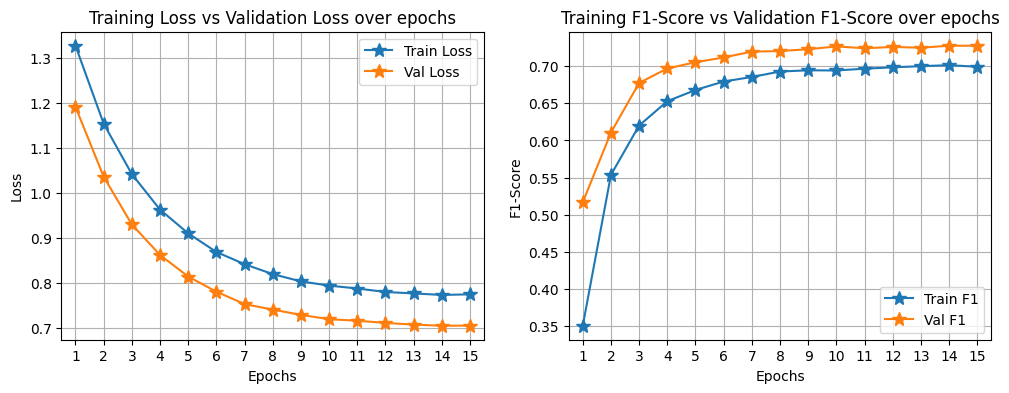

Stage:  17%|█▋        | 1/6 [00:00<00:03,  1.35stage/s]


Training of stage "classifier" completed in 0.01 minutes.

Model type: DenseNet
Layer parameters that are NOT frozen at this stage are:
features.denseblock4.denselayer1.norm1.weight True
features.denseblock4.denselayer1.norm1.bias True
features.denseblock4.denselayer1.conv1.weight True
features.denseblock4.denselayer1.norm2.weight True
features.denseblock4.denselayer1.norm2.bias True
features.denseblock4.denselayer1.conv2.weight True
features.denseblock4.denselayer2.norm1.weight True
features.denseblock4.denselayer2.norm1.bias True
features.denseblock4.denselayer2.conv1.weight True
features.denseblock4.denselayer2.norm2.weight True
features.denseblock4.denselayer2.norm2.bias True
features.denseblock4.denselayer2.conv2.weight True
features.denseblock4.denselayer3.norm1.weight True
features.denseblock4.denselayer3.norm1.bias True
features.denseblock4.denselayer3.conv1.weight True
features.denseblock4.denselayer3.norm2.weight True
features.denseblock4.denselayer3.norm2.bias True
features

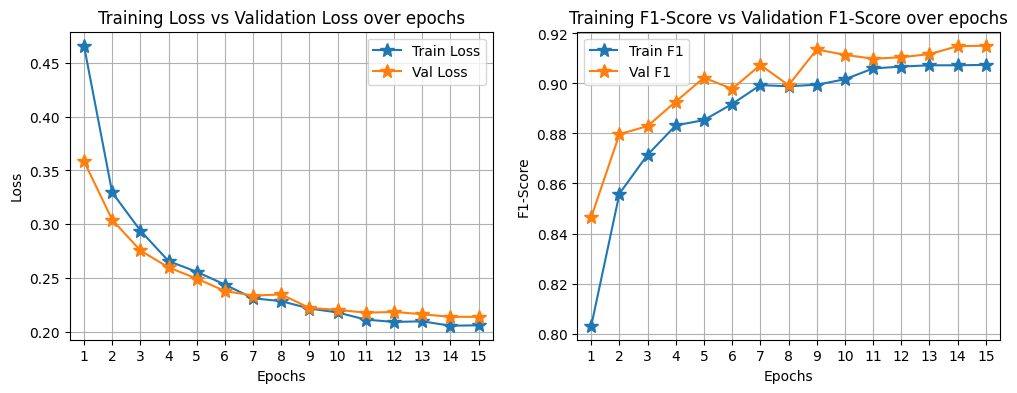

Stage:  33%|███▎      | 2/6 [00:01<00:03,  1.31stage/s]


Training of stage "features.denseblock4" completed in 0.01 minutes.

Model type: DenseNet
Layer parameters that are NOT frozen at this stage are:
features.denseblock3.denselayer1.norm1.weight True
features.denseblock3.denselayer1.norm1.bias True
features.denseblock3.denselayer1.conv1.weight True
features.denseblock3.denselayer1.norm2.weight True
features.denseblock3.denselayer1.norm2.bias True
features.denseblock3.denselayer1.conv2.weight True
features.denseblock3.denselayer2.norm1.weight True
features.denseblock3.denselayer2.norm1.bias True
features.denseblock3.denselayer2.conv1.weight True
features.denseblock3.denselayer2.norm2.weight True
features.denseblock3.denselayer2.norm2.bias True
features.denseblock3.denselayer2.conv2.weight True
features.denseblock3.denselayer3.norm1.weight True
features.denseblock3.denselayer3.norm1.bias True
features.denseblock3.denselayer3.conv1.weight True
features.denseblock3.denselayer3.norm2.weight True
features.denseblock3.denselayer3.norm2.bias Tru

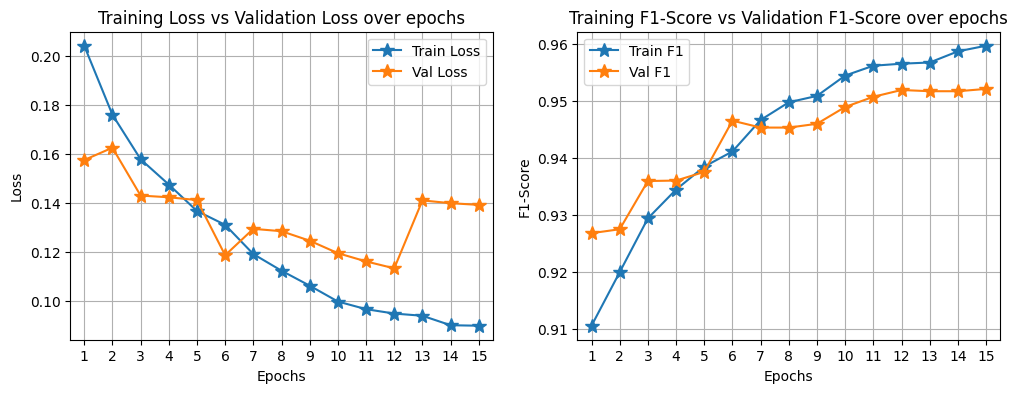

Stage:  50%|█████     | 3/6 [00:02<00:02,  1.22stage/s]


Training of stage "features.denseblock3" completed in 0.01 minutes.

Model type: DenseNet
Layer parameters that are NOT frozen at this stage are:
features.denseblock2.denselayer1.norm1.weight True
features.denseblock2.denselayer1.norm1.bias True
features.denseblock2.denselayer1.conv1.weight True
features.denseblock2.denselayer1.norm2.weight True
features.denseblock2.denselayer1.norm2.bias True
features.denseblock2.denselayer1.conv2.weight True
features.denseblock2.denselayer2.norm1.weight True
features.denseblock2.denselayer2.norm1.bias True
features.denseblock2.denselayer2.conv1.weight True
features.denseblock2.denselayer2.norm2.weight True
features.denseblock2.denselayer2.norm2.bias True
features.denseblock2.denselayer2.conv2.weight True
features.denseblock2.denselayer3.norm1.weight True
features.denseblock2.denselayer3.norm1.bias True
features.denseblock2.denselayer3.conv1.weight True
features.denseblock2.denselayer3.norm2.weight True
features.denseblock2.denselayer3.norm2.bias Tru

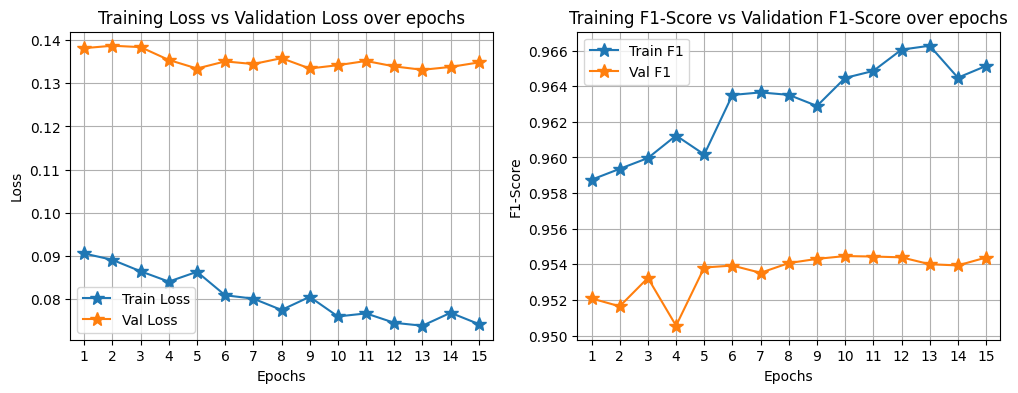

Stage:  67%|██████▋   | 4/6 [00:03<00:01,  1.10stage/s]


Training of stage "features.denseblock2" completed in 0.01 minutes.

Model type: DenseNet
Layer parameters that are NOT frozen at this stage are:
features.denseblock1.denselayer1.norm1.weight True
features.denseblock1.denselayer1.norm1.bias True
features.denseblock1.denselayer1.conv1.weight True
features.denseblock1.denselayer1.norm2.weight True
features.denseblock1.denselayer1.norm2.bias True
features.denseblock1.denselayer1.conv2.weight True
features.denseblock1.denselayer2.norm1.weight True
features.denseblock1.denselayer2.norm1.bias True
features.denseblock1.denselayer2.conv1.weight True
features.denseblock1.denselayer2.norm2.weight True
features.denseblock1.denselayer2.norm2.bias True
features.denseblock1.denselayer2.conv2.weight True
features.denseblock1.denselayer3.norm1.weight True
features.denseblock1.denselayer3.norm1.bias True
features.denseblock1.denselayer3.conv1.weight True
features.denseblock1.denselayer3.norm2.weight True
features.denseblock1.denselayer3.norm2.bias Tru

Evaluating: 100%|██████████| 66/66 [00:54<00:00,  1.21batch/s]


[DRIVE CHECKPOINT] Saved: /content/drive/MyDrive/hackathon_checkpoints/densenet_aug/features.denseblock1_checkpoint_epoch_0.pt
Epoch 1 [features.denseblock1]: Train Loss = 0.0783 | Train F1 = 0.9649 | Val Loss = 0.1406 | Val F1 = 0.9544 | LR = 9.90e-06 | Time = 191.47s

*************************************************  Running epoch: 2 out of 15  ****************************************************


Evaluating: 100%|██████████| 66/66 [00:54<00:00,  1.20batch/s]


...

[DRIVE CHECKPOINT] Saved: /content/drive/MyDrive/hackathon_checkpoints/densenet_aug/features.denseblock1_checkpoint_epoch_12.pt
Epoch 13 [features.denseblock1]: Train Loss = 0.0630 | Train F1 = 0.9709 | Val Loss = 0.1303 | Val F1 = 0.9574 | LR = 1.39e-06 | Time = 189.60s

*************************************************  Running epoch: 14 out of 15  ****************************************************


Evaluating: 100%|██████████| 66/66 [00:55<00:00,  1.20batch/s]


[DRIVE CHECKPOINT] Saved: /content/drive/MyDrive/hackathon_checkpoints/densenet_aug/features.denseblock1_checkpoint_epoch_13.pt
Epoch 14 [features.denseblock1]: Train Loss = 0.0605 | Train F1 = 0.9714 | Val Loss = 0.1324 | Val F1 = 0.9584 | LR = 1.10e-06 | Time = 189.44s

*************************************************  Running epoch: 15 out of 15  ****************************************************


Evaluating: 100%|██████████| 66/66 [00:54<00:00,  1.21batch/s]


[DRIVE CHECKPOINT] Saved: /content/drive/MyDrive/hackathon_checkpoints/densenet_aug/features.denseblock1_checkpoint_epoch_14.pt
Epoch 15 [features.denseblock1]: Train Loss = 0.0583 | Train F1 = 0.9729 | Val Loss = 0.1303 | Val F1 = 0.9578 | LR = 1.00e-06 | Time = 189.37s
########################################################################################
Saved model to /content/drive/MyDrive/oct_models/densenet_aug/densenet_features.denseblock1_best.pth
########################################################################################

The loss and training curves at stage features.denseblock1 are:

Plot saved to: /content/drive/MyDrive/plots/densenet_aug/stage_features.denseblock1_training_not_aug.png


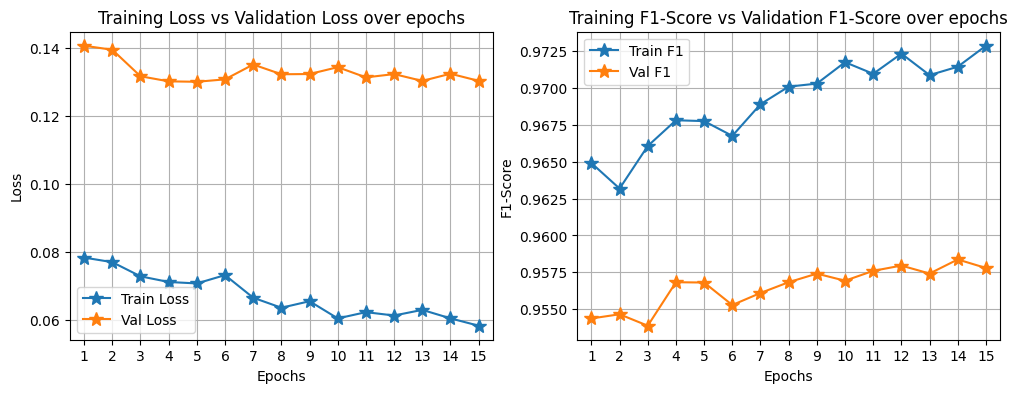

Stage:  83%|████████▎ | 5/6 [47:32<17:07, 1027.92s/stage]


Training of stage "features.denseblock1" completed in 47.48 minutes.

No layers are frozen, all layers are trainable.

Loading best model from previous stage: features.denseblock1 for stage None
Starting stage 'None' from epoch 1 with LR = 1.00e-05
---------------------------------------------------------------------------------------------------------------------------------

*************************************************  Running epoch: 1 out of 15  ****************************************************


Evaluating: 100%|██████████| 66/66 [00:54<00:00,  1.22batch/s]


[DRIVE CHECKPOINT] Saved: /content/drive/MyDrive/hackathon_checkpoints/densenet_aug/None_checkpoint_epoch_0.pt
Epoch 1 [None]: Train Loss = 0.0630 | Train F1 = 0.9718 | Val Loss = 0.1278 | Val F1 = 0.9570 | LR = 9.90e-06 | Time = 189.25s

*************************************************  Running epoch: 2 out of 15  ****************************************************


Evaluating: 100%|██████████| 66/66 [00:55<00:00,  1.19batch/s]


...

[DRIVE CHECKPOINT] Saved: /content/drive/MyDrive/hackathon_checkpoints/densenet_aug/None_checkpoint_epoch_9.pt
Epoch 10 [None]: Train Loss = 0.0490 | Train F1 = 0.9765 | Val Loss = 0.1335 | Val F1 = 0.9604 | LR = 3.25e-06 | Time = 189.73s

*************************************************  Running epoch: 11 out of 15  ****************************************************


Evaluating: 100%|██████████| 66/66 [00:54<00:00,  1.22batch/s]


[DRIVE CHECKPOINT] Saved: /content/drive/MyDrive/hackathon_checkpoints/densenet_aug/None_checkpoint_epoch_10.pt
Epoch 11 [None]: Train Loss = 0.0497 | Train F1 = 0.9762 | Val Loss = 0.1356 | Val F1 = 0.9603 | LR = 2.49e-06 | Time = 189.69s

*************************************************  Running epoch: 12 out of 15  ****************************************************


Evaluating: 100%|██████████| 66/66 [00:54<00:00,  1.21batch/s]


[DRIVE CHECKPOINT] Saved: /content/drive/MyDrive/hackathon_checkpoints/densenet_aug/None_checkpoint_epoch_11.pt
Epoch 12 [None]: Train Loss = 0.0493 | Train F1 = 0.9762 | Val Loss = 0.1353 | Val F1 = 0.9596 | LR = 1.86e-06 | Time = 189.04s
Early stopping triggered!
########################################################################################
Saved model to /content/drive/MyDrive/oct_models/densenet_aug/densenet_None_best.pth
########################################################################################
!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!
Stopping early at epoch 12

The loss and training curves at stage None are:

Plot saved to: /content/drive/MyDrive/plots/densenet_aug/stage_full_training_not_aug.png


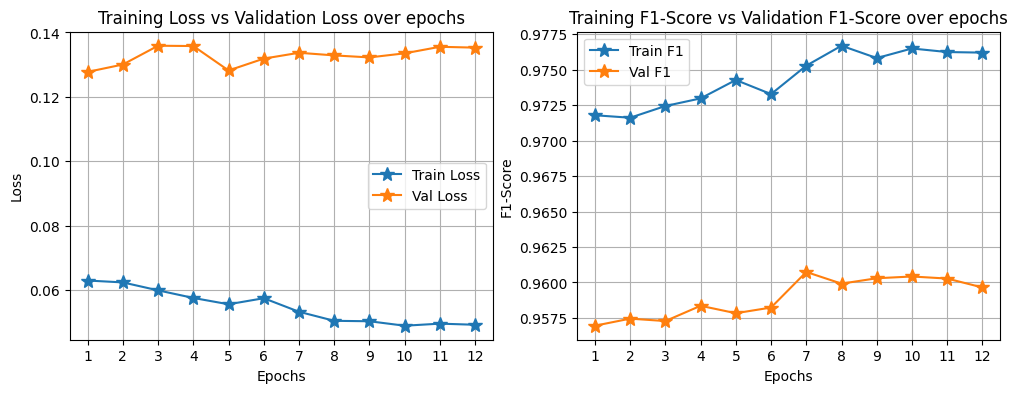

Stage: 100%|██████████| 6/6 [1:25:32<00:00, 855.48s/stage] 


Training of stage "None" completed in 38.01 minutes.

#################################################################################################################################


In [ ]:
print("#" * 129)
print("Please wait until training the \"oct-classification model\" is done.")
prev_stage=None

for stage in tqdm(stages, desc='Stage', unit='stage', position=0, leave=True):
    lr = 1e-4  if stage in ['classifier', 'features.denseblock4', 'features.denseblock3'] else 1e-5 # initial learning rate
    # Check if stage is completed by finding if best model exists
    best_model_path = os.path.join('oct_models', f"densenet_{stage}_best.pth")
    if os.path.exists(best_model_path):
        print(f"[INFO] Best model for {stage} already exists. Skipping to next stage.")
        prev_stage = stage
        continue

    early_stopping = utils.Early_Stopping_densenet()

    # Freeze layers for the stage
    utils.freeze_first_n_layers(model, stage)

    # Setup optimizer & scheduler
    optimizer = torch.optim.Adam(filter(lambda p: p.requires_grad, model.parameters()), lr=lr)
    scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=num_epochs, eta_min=1e-6)

    # Load checkpoint if it exists
    (model, optimizer, scheduler, start_epoch,
     train_epoch_losses, train_epoch_f1s,
     val_epoch_losses, val_epoch_f1s,
     num_epochs_checkpoint, data_fraction_checkpoint) = utils.load_latest_checkpoint(model, optimizer, scheduler,
                                                                                     stage, path=path_hackathon_checkpoints, device=device)

    if start_epoch == 0 and prev_stage is not None:
        current_prev_best_path = os.path.join(path_oct_models, f"densenet_{prev_stage}_best.pth")
        if os.path.exists(current_prev_best_path):
            print(f"Loading best model from previous stage: {prev_stage} for stage {stage}")
            model.load_state_dict(torch.load(current_prev_best_path, map_location=device))
        else:
            print(f"No best model found for previous stage: {prev_stage}, starting from current model weights.")

    resumed_lr = optimizer.param_groups[0]['lr']
    stage_start = time.time()
    print(f"Starting stage '{stage}' from epoch {start_epoch + 1} with LR = {resumed_lr:.2e}")
    print("-" * 129)

    for epoch in range(start_epoch, num_epochs):
        epoch_start = time.time()
        print("")
        print("*" * 49, f" Running epoch: {epoch + 1} out of {num_epochs} ", "*" * 52)

        # Train + Evaluate
        train_epoch_loss, train_epoch_f1 = utils.train_model(model, train_loader, criterion, optimizer, device)
        val_epoch_loss, val_epoch_f1 = utils.evaluate(model, val_loader, criterion, device)

        # Update LR
        scheduler.step()
        current_lr = optimizer.param_groups[0]['lr']

        # Accumulate metrics
        train_epoch_losses.append(train_epoch_loss)
        train_epoch_f1s.append(train_epoch_f1)
        val_epoch_losses.append(val_epoch_loss)
        val_epoch_f1s.append(val_epoch_f1)

        # Save checkpoint
        utils.save_checkpoint(model, optimizer, scheduler, stage, epoch,
                        train_epoch_losses, train_epoch_f1s,
                        val_epoch_losses, val_epoch_f1s,
                        num_epochs=num_epochs,
                        data_fraction=1.0,
                        path=path_hackathon_checkpoints)

        epoch_time = time.time() - epoch_start
        print("=" * 129)
        print(
            f"Epoch {epoch + 1} [{stage}]: "
            f"Train Loss = {train_epoch_loss:.4f} | Train F1 = {train_epoch_f1:.4f} | "
            f"Val Loss = {val_epoch_loss:.4f} | Val F1 = {val_epoch_f1:.4f} | "
            f"LR = {current_lr:.2e} | Time = {epoch_time:.2f}s"
        )
        print("=" * 129)

        # Early stopping
        early_stopping(val_epoch_f1, val_epoch_loss, model)
        if early_stopping.early_stop:
            model.load_state_dict(early_stopping.best_state)
            best_model = copy.deepcopy(model)
            utils.save_best_model(best_model, "densenet", stage, path_to_models=path_oct_models)
            print("!" * 40)
            print(f"Stopping early at epoch {epoch + 1}")
            break

    # Save best model if early stop did not trigger
    if not early_stopping.early_stop and early_stopping.best_state is not None:
        model.load_state_dict(early_stopping.best_state)
        best_model = copy.deepcopy(model)
        utils.save_best_model(best_model, "densenet", stage, path_to_models=path_oct_models)

    # Plot curves using accumulated metrics (including resumed epochs)
    print(f"\nThe loss and training curves at stage {stage} are:\n")
    utils.loss_train_curve_plots(
        num_epochs=len(train_epoch_losses),
        train_epoch_losses=train_epoch_losses,
        train_epoch_f1s=train_epoch_f1s,
        val_epoch_losses=val_epoch_losses,
        val_epoch_f1s=val_epoch_f1s,
        save_plot=True,
        stage=stage,
        model_name='densenet',
        augmented=True,
        path_plots=path_plots
    )

    total_stage_time = time.time() - stage_start
    print(f"\nTraining of stage \"{stage}\" completed in {total_stage_time / 60:.2f} minutes.\n")
    prev_stage = stage
print("#" * 129)

Extracted 87 total epochs across 6 stages.
Best models identified at global epoch indices: [13, 28, 41, 54, 71, 81]


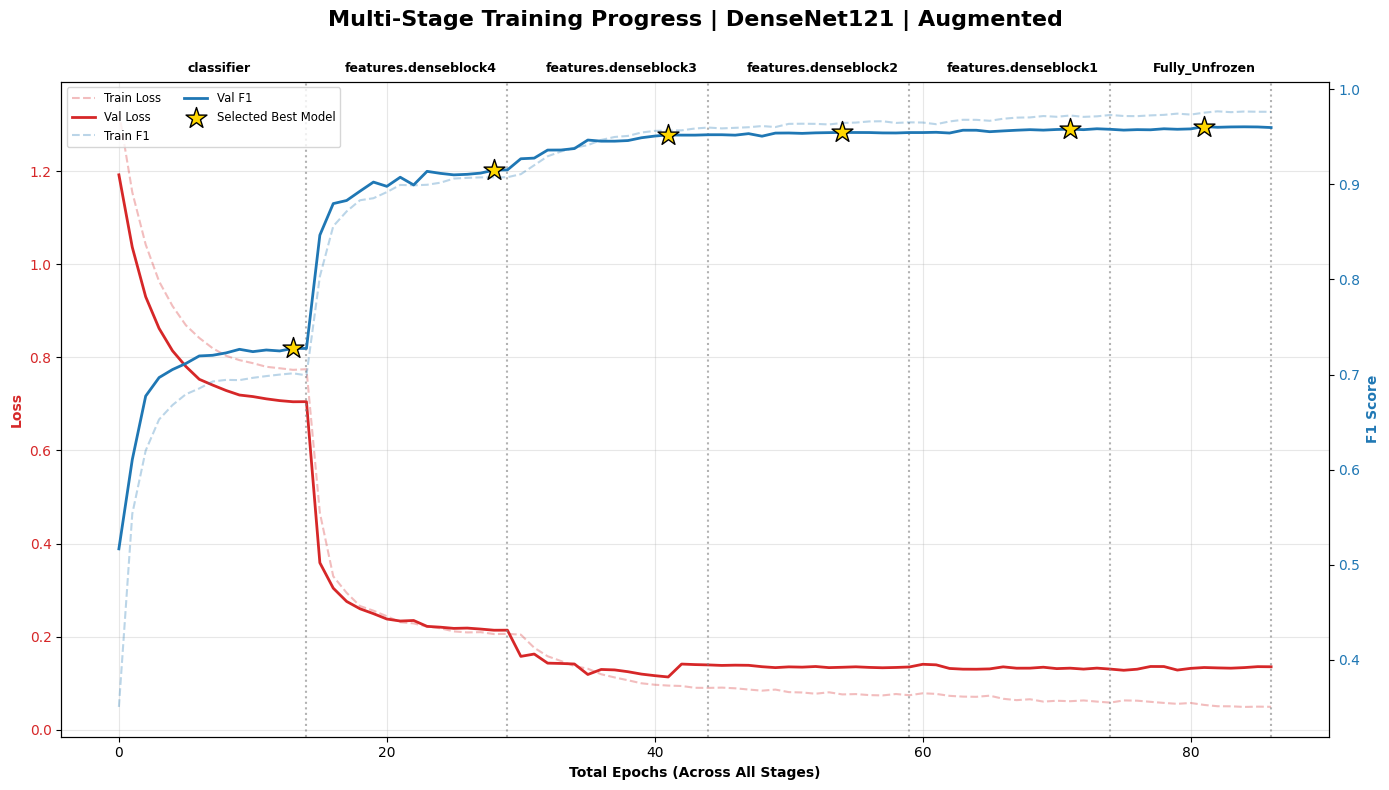

In [18]:
# Extract all the data from checkpoints
metrics_dict = utils.extract_all_metrics(stages, path_hackathon_checkpoints, model_name="DenseNet121")

# Check if data exists
if not metrics_dict['val_loss']:
    print("No metrics found. Check your stage names and checkpoint path.")
else:
    total_epochs = len(metrics_dict['val_loss'])
    print(f"Extracted {total_epochs} total epochs across {len(stages)} stages.")
    print(f"Best models identified at global epoch indices: {metrics_dict['best_indices']}")

    # Generate the visualization once for inspection
    utils.plot_multi_stage_metrics(
        metrics=metrics_dict,
        stages=stages,
        model_name='DenseNet121',
        is_augmented=True
    )
plt.show()

Choose the epoch index of the final model to highlight: 41
Plot saved to: /content/drive/MyDrive/plots/densenet_aug


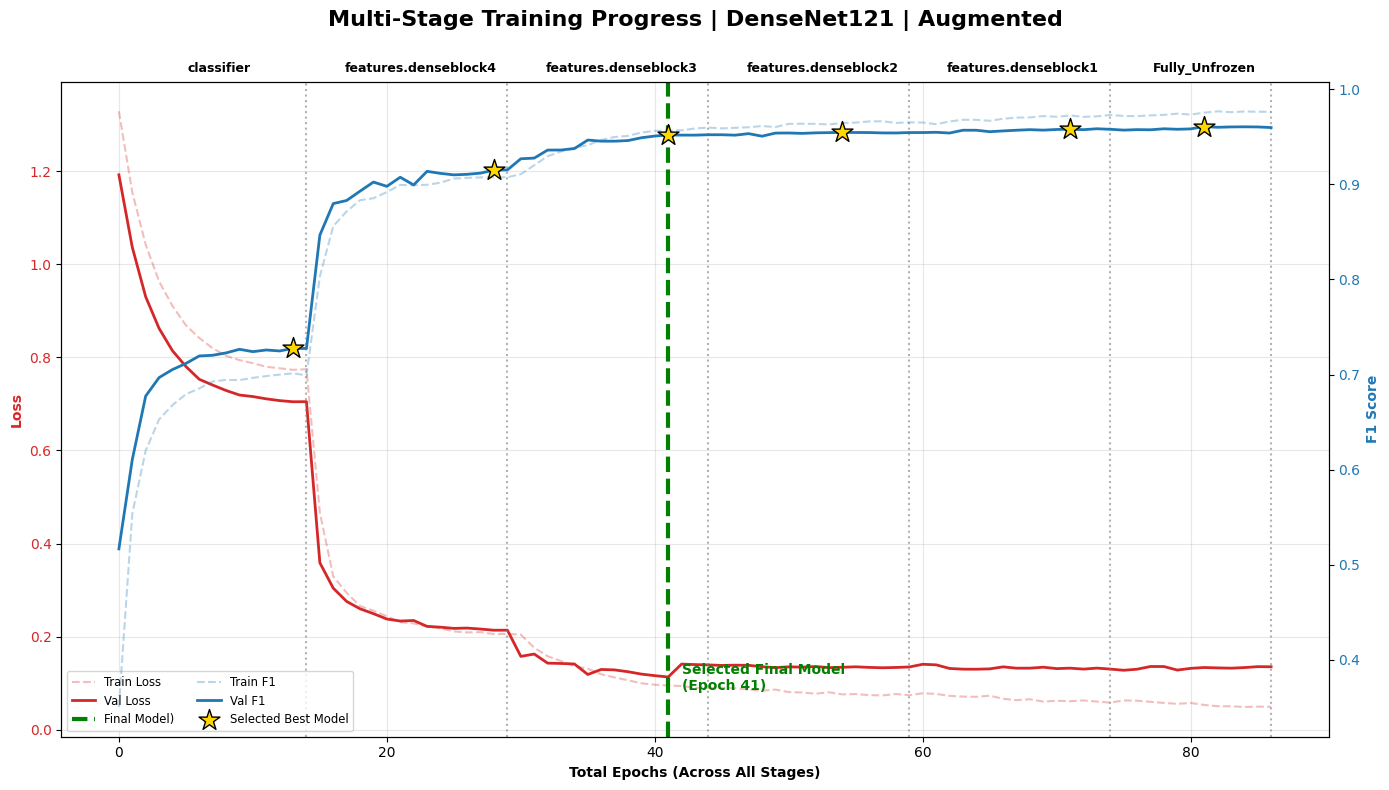

In [21]:
# Generate the plot again to show best model
utils.plot_multi_stage_metrics(
    metrics=metrics_dict,
    stages=stages,
    model_name='DenseNet121',
    is_augmented=True
)

# Epoch 41 should be chosen
target_epoch = int(input("Choose the epoch index of the final model to highlight: "))
ax1 = plt.gcf().axes[0]  # Get the Loss axis
ax2 = plt.gcf().axes[1]  # Get the F1 axis

# Draw the selection line
line_selection = ax1.axvline(x=target_epoch, color='green', linestyle='--',
                             linewidth=3, label='Final Model)')

# Add the text annotation
ax1.text(target_epoch + 1, ax1.get_ylim()[0] + 0.1, f'Selected Final Model\n(Epoch {target_epoch})',
         color='green', fontweight='bold')

# Gather all handles and labels from both axes
h1, l1 = ax1.get_legend_handles_labels()
h2, l2 = ax2.get_legend_handles_labels()

# Remove the old legend
if ax1.get_legend(): ax1.get_legend().remove()
if ax2.get_legend(): ax2.get_legend().remove()

# Create one final combined legend on ax1 or ax2
ax1.legend(h1 + h2, l1 + l2, loc='lower left', ncol=2, fontsize='small', frameon=True)

# Save and show
plt.savefig(path_plots, bbox_inches='tight', dpi=300)
print(f"Plot saved to: {path_plots}")
plt.show()

In [ ]:
# Define paths
# Epoch 41 is concidentally the best model saved already
model_path = os.path.join(path_oct_models, "densenet_features.denseblock3_best.pth")
os.makedirs(path_final_models, exist_ok=True)
final_model_save_path = os.path.join(path_final_models, "densenet_augmented_final.pth")

if os.path.exists(model_path):
    final_model = torch.load(model_path, map_location='cpu')

    # Save as your final model file
    torch.save(final_model, final_model_save_path)

    print(f"Successfully extracted Epoch 41 from stage 'features.denseblock3'.")
    print(f"Final model saved to: {final_model_save_path}")
else:
    print(f"Error: Could not find the file at {model_path}")

Successfully extracted Epoch 41 from stage 'features.denseblock3'.
Final model saved to: /content/drive/MyDrive/Final_Models/densenet_augmented_final.pth


In [18]:
# Evaluate the final model
final_model_state_dict = torch.load(os.path.join(path_final_models, "densenet_augmented_final.pth"), map_location=device)
model.load_state_dict(final_model_state_dict)
final_model = copy.deepcopy(model)

results = utils.evaluate_val_split(final_model, val_loader, device, model_name,  path_final_models)

Vault Export: densenet: 100%|██████████| 33/33 [00:56<00:00,  1.71s/it]


In [59]:
results['report']

,precision,recall,f1-score,support
CNV,0.987402,0.964682,0.975910,7475.000000
DME,0.952320,0.965056,0.958646,2318.000000
DRUSEN,0.880417,0.912450,0.896147,1759.000000
NORMAL,0.970610,0.984714,0.977611,5299.000000
accuracy,0.965581,0.965581,0.965581,0.965581
macro avg,0.947687,0.956726,0.952079,16851.000000
weighted avg,0.966128,0.965581,0.965744,16851.000000


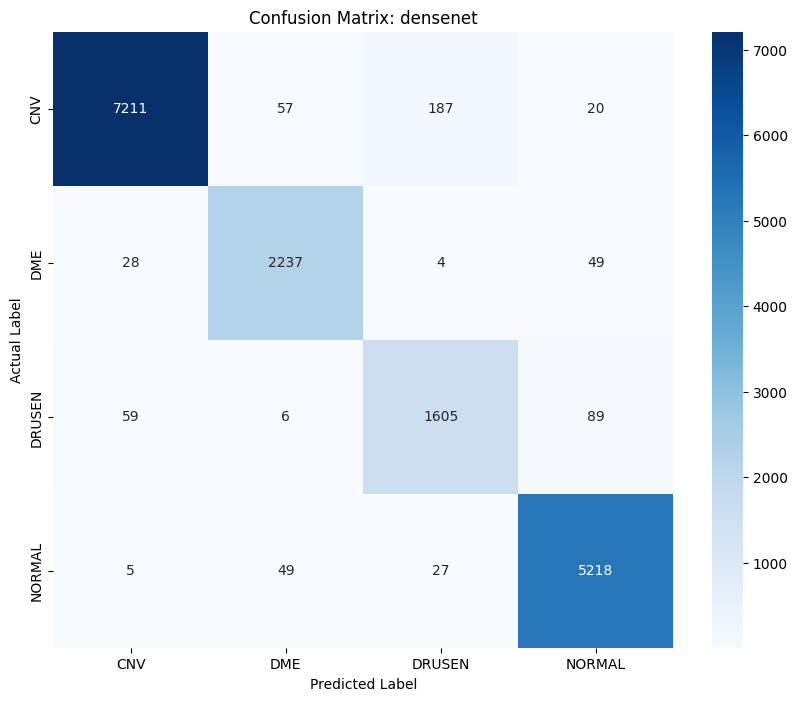

In [23]:
cm_df = results['confusion_matrix']
plt.figure(figsize=(10, 8))

# Create heatmap
sns.heatmap(cm_df, annot=True, fmt='d', cmap='Blues', cbar=True)

plt.title(f'Confusion Matrix | {model_name}')
plt.ylabel('Actual Label')
plt.xlabel('Predicted Label')
plt.show()

In [46]:
final_model_state_dict = torch.load(os.path.join(path_final_models, "densenet_augmented_final.pth"), map_location=device)
model.load_state_dict(final_model_state_dict)
final_model = copy.deepcopy(model)

In [47]:
# Do fine-tuning refinement to the final model selected
# Hard Example Mining + Class-Specific Refinement

# Remove shuffling from train_loader
train_loader_hard = DataLoader(fraction_train_dataset, batch_size=BATCH_SIZE, num_workers=8, persistent_workers=True,
                          prefetch_factor=2, shuffle=False, pin_memory=True)

# Identify Hard Samples (TRAIN SET ONLY)
def collect_hard_examples(final_model, loader, device, threshold=0.9):
    final_model.eval()
    hard_indices = []

    # Track class distribution of hard samples
    class_stats = {0: 0, 1: 0, 2: 0, 3: 0}

    with torch.no_grad():
        # Use enumerate to get the batch index
        for batch_idx, (images, labels) in enumerate(tqdm(loader, desc="Hard Mining")):
            images, labels = images.to(device), labels.to(device)

            outputs = final_model(images)
            probs = torch.softmax(outputs, dim=1)

            # Get max probability and predicted class
            confs, preds = torch.max(probs, dim=1)

            for i in range(len(labels)):
                # Calculate the ABSOLUTE index in the dataset
                global_idx = batch_idx * loader.batch_size + i

                # Logic: Prediction is wrong AND model was very sure
                if preds[i] != labels[i] and confs[i] > threshold:
                    hard_indices.append(global_idx)
                    class_stats[labels[i].item()] += 1

    print(f"\nFound {len(hard_indices)} 'Confidently Incorrect' samples.")
    print(f"Distribution of errors by True Class: {class_stats}")
    return hard_indices


hard_indices = collect_hard_examples(final_model, train_loader_hard, device)

Hard Mining: 100%|██████████| 99/99 [02:13<00:00,  1.35s/it]


Found 342 'Confidently Incorrect' samples.
Distribution of errors by True Class: {0: 207, 1: 18, 2: 49, 3: 68}


In [48]:
# Create Weighted Sampler (Boost DRUSEN + Hard Cases)
def create_weighted_sampler(dataset, hard_indices):
    labels = dataset.df['label_encoded'].values
    weights = np.ones(len(labels), dtype=np.float64)

    weights[labels == 2] *= 1.5

    hard_indices_set = set(hard_indices)
    for idx in hard_indices:
        weights[idx] *= 3.0

    weights = np.nan_to_num(weights, nan=1.0, posinf=10.0)
    weights[weights <= 0] = 1e-7

    torch_weights = torch.from_numpy(weights).to(torch.double)

    return WeightedRandomSampler(weights=torch_weights, num_samples=len(torch_weights), replacement=True)

In [49]:
sampler = create_weighted_sampler(train_dataset, hard_indices)

In [50]:
refinement_loader = DataLoader(
    dataset=fraction_train_dataset,
    batch_size=BATCH_SIZE,
    sampler=sampler,
    num_workers=8,
    pin_memory=True
)

In [51]:
def unfreeze_last_block_densenet(final_model):
    # Freeze everything first
    for param in final_model.parameters():
        param.requires_grad = False

    # Unfreeze the final dense block and the final transition/norm layers
    for param in final_model.features.denseblock4.parameters():
        param.requires_grad = True
    for param in final_model.features.norm5.parameters():
        param.requires_grad = True

    # Unfreeze the classifier (DenseNet uses 'classifier', not 'fc')
    for param in final_model.classifier.parameters():
        param.requires_grad = True

    print("Unfroze classifier + denseblock4")

unfreeze_last_block_densenet(final_model)


# Use Label Smoothing
criterion = torch.nn.CrossEntropyLoss(label_smoothing=0.05)

# Optimizer
optimizer = torch.optim.Adam(filter(lambda p: p.requires_grad, final_model.parameters()), lr=1e-5)

def fine_tune(final_model, train_loader, val_loader, optimizer, criterion, device, epochs=5, path_final_models=path_final_models):
    best_val_loss = float('inf')
    path = os.path.join(path_final_models, "densenet_refined.pth")
    for epoch in range(epochs):
        # Training
        final_model.train()
        total_train_loss = 0
        for images, labels in tqdm(train_loader, desc=f"Epoch {epoch+1} [Train]", position=0, leave=True):
            images, labels = images.to(device), labels.to(device)

            optimizer.zero_grad()
            outputs = final_model(images)
            loss = criterion(outputs, labels)
            loss.backward()
            optimizer.step()
            total_train_loss += loss.item()

        # Validation
        final_model.eval()
        total_val_loss = 0
        with torch.no_grad():
            for images, labels in val_loader:
                images, labels = images.to(device), labels.to(device)
                outputs = final_model(images)
                loss = criterion(outputs, labels)
                total_val_loss += loss.item()

        avg_train = total_train_loss / len(train_loader)
        avg_val = total_val_loss / len(val_loader)

        print(f"Epoch {epoch+1}: Train Loss: {avg_train:.4f} | Val Loss: {avg_val:.4f}")

        # Save only the best weights
        if avg_val < best_val_loss:
            best_val_loss = avg_val
            torch.save(final_model.state_dict(), path)
            print(f"Best model weights updated and saved at: {path}")

fine_tune(final_model, refinement_loader, val_loader, optimizer, criterion, device, epochs=5)

Unfroze classifier + denseblock4


Epoch 1 [Train]: 100%|██████████| 99/99 [02:19<00:00,  1.41s/it]


Epoch 1: Train Loss: 0.3885 | Val Loss: 0.3673
Best model weights updated and saved at: /content/drive/MyDrive/Final_Models/densenet_aug/densenet_refined.pth


Epoch 2 [Train]: 100%|██████████| 99/99 [02:13<00:00,  1.35s/it]


Epoch 2: Train Loss: 0.3375 | Val Loss: 0.3401
Best model weights updated and saved at: /content/drive/MyDrive/Final_Models/densenet_aug/densenet_refined.pth


...

Epoch 3: Train Loss: 0.3187 | Val Loss: 0.3260
Best model weights updated and saved at: /content/drive/MyDrive/Final_Models/densenet_aug/densenet_refined.pth


Epoch 4 [Train]: 100%|██████████| 99/99 [02:12<00:00,  1.34s/it]


Epoch 4: Train Loss: 0.3135 | Val Loss: 0.3174
Best model weights updated and saved at: /content/drive/MyDrive/Final_Models/densenet_aug/densenet_refined.pth


Epoch 5 [Train]: 100%|██████████| 99/99 [02:15<00:00,  1.37s/it]


Epoch 5: Train Loss: 0.3060 | Val Loss: 0.3125
Best model weights updated and saved at: /content/drive/MyDrive/Final_Models/densenet_aug/densenet_refined.pth


In [52]:
# Inference using the final refined model
final_model.eval()

all_preds = []
all_probs = []
all_labels = []

with torch.no_grad():
    for images, labels in tqdm(test_loader, desc="Testing", unit="batch", position=0, leave=True):
        images, labels = images.to(device), labels.to(device)

        outputs = final_model(images)
        probs = torch.softmax(outputs, dim=1)
        preds = probs.argmax(dim=1)

        all_preds.append(preds.cpu())
        all_probs.append(probs.cpu())
        all_labels.append(labels.cpu())

# Flatten tensors to numpy arrays
gold = torch.cat(all_labels).numpy()
preds = torch.cat(all_preds).numpy()
probs = torch.cat(all_probs).numpy()

# Save results for persistence
torch.save({
    "gold_labels": gold,
    "predictions": preds,
    "probabilities": probs,
}, f"{path_final_models}/test_predictions_refined_test.pth")
print("Predictions saved and loaded successfully!")

class_names = ["CNV", "DME", "DRUSEN", "NORMAL"]
threshold = 0.9

# Calculate confidence for the chosen class and boolean correct mask
pred_conf = probs[np.arange(len(preds)), preds]
correct = (preds == gold)

# General High-Confidence Error Stats
high_conf_wrong_mask = (~correct) & (pred_conf > threshold)
high_conf_wrong_total = np.sum(high_conf_wrong_mask)

print(f"\nOVERALL STATS:")
print(f"High-confidence wrong: {high_conf_wrong_total}/{len(preds)} = {100*high_conf_wrong_total/len(preds):.2f}%")

Testing: 100%|██████████| 33/33 [01:48<00:00,  3.28s/batch]

Predictions saved and loaded successfully!

OVERALL STATS:
High-confidence wrong: 103/16699 = 0.62%


In [53]:
# Load and force into NumPy arrays for plotting consistency
data = torch.load("test_predictions_refined_test.pth", weights_only=False)
gold = np.array(data["gold_labels"])
preds = np.array(data["predictions"])
probs = np.array(data["probabilities"])

class_names = ["CNV", "DME", "DRUSEN", "NORMAL"]
class_colors = ["#d62728", "#1f77b4", "#2ca02c", "#ff7f0e"] # Red, Blue, Green, Orange
threshold = 0.9
path_final_plots = "./plots"

# --- 2. OFFICIAL STATS & REPORT ---
print("--- FINAL REFINED MODEL EVALUATION ---")
print(classification_report(gold, preds, target_names=class_names, digits=4))

--- FINAL REFINED MODEL EVALUATION ---
              precision    recall  f1-score   support

         CNV     0.9727    0.9793    0.9760      7432
         DME     0.9662    0.9472    0.9566      2293
      DRUSEN     0.9184    0.8471    0.8813      1714
      NORMAL     0.9634    0.9869    0.9750      5260

    accuracy                         0.9637     16699
   macro avg     0.9552    0.9401    0.9472     16699
weighted avg     0.9633    0.9637    0.9633     16699



OVERALL STATS:
High-confidence wrong: 103/16699
Plot saved to ./plots/densenet_refined_cm_roc_aug.png


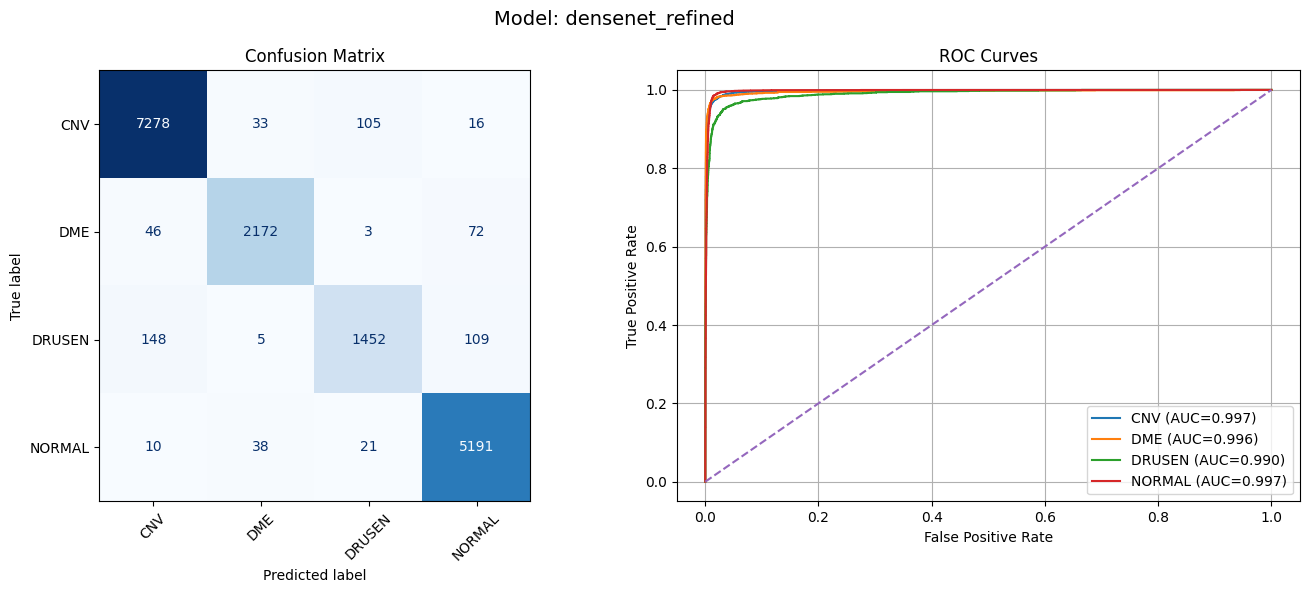

In [54]:
# Confidence and Error Masks
pred_conf = probs[np.arange(len(preds)), preds]
correct = (preds == gold)
high_conf_wrong_mask = (~correct) & (pred_conf > threshold)

print(f"OVERALL STATS:")
print(f"High-confidence wrong: {np.sum(high_conf_wrong_mask)}/{len(preds)}")

# --- 3. THE "UTILS" PLOT (CM & ROC) ---
# Calls your specific function: (gold, preds, probs, names, path, aug, name)
utils.plot_cm_and_roc_single_stage(
    gold,
    preds,
    probs,
    class_names,
    path_final_plots,
    True,               # augmented
    "densenet_refined"  # model_name
)

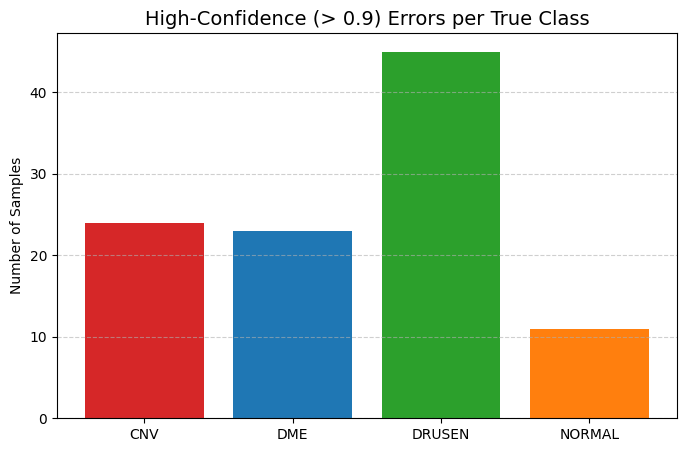

In [57]:
# --- 4. ERROR ANALYSIS VISUALIZATIONS ---

# A. Bar Plot: High-Confidence Errors per True Class
misclassified_counts = [np.sum((gold == i) & high_conf_wrong_mask) for i in range(4)]

plt.figure(figsize=(8, 5))
plt.bar(class_names, misclassified_counts, color=class_colors)
plt.title(f"High-Confidence (> {threshold}) Errors per True Class", fontsize=14)
plt.ylabel("Number of Samples")
plt.grid(axis='y', linestyle='--', alpha=0.6)
plt.show()

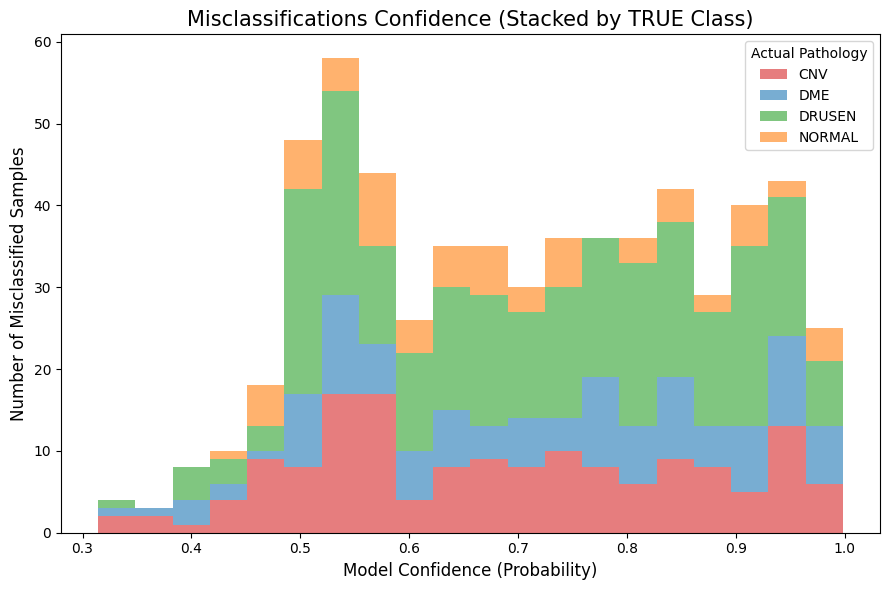

In [56]:
# B. Stacked Histogram: Confidence grouped by TRUE CLASS
# This shows exactly which actual diseases the model is missing confidently
incorrect_conf_by_true_class = [
    pred_conf[(gold == i) & (~correct)]
    for i in range(len(class_names))
]

plt.figure(figsize=(9, 6))
plt.hist(
    incorrect_conf_by_true_class,
    bins=20,
    stacked=True,
    color=class_colors,
    label=class_names,
    alpha=0.6
)
plt.xlabel("Model Confidence (Probability)", fontsize=12)
plt.ylabel("Number of Misclassified Samples", fontsize=12)
plt.title("Misclassifications Confidence (Stacked by TRUE Class)", fontsize=15)
plt.legend(title="Actual Pathology")
plt.tight_layout()
plt.savefig(f"{path_final_plots}/confidence_stacked_true_class.png", dpi=300)
plt.show()

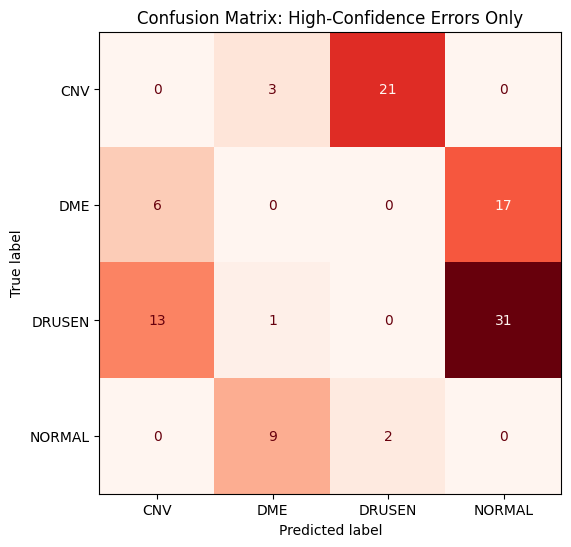

In [55]:
if np.sum(high_conf_wrong_mask) > 0:
    hc_cm = confusion_matrix(gold[high_conf_wrong_mask], preds[high_conf_wrong_mask], labels=range(4))
    disp = ConfusionMatrixDisplay(confusion_matrix=hc_cm, display_labels=class_names)
    fig, ax = plt.subplots(figsize=(6, 6))
    disp.plot(cmap="Reds", ax=ax, colorbar=False)
    ax.set_title(f"Confusion Matrix: High-Confidence Errors Only")
    plt.show()